In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
# Import data
df   = pd.read_csv('https://raw.githubusercontent.com/NUELBUNDI/Machine-Learning-Data-Set/main/insurance%20Regression.csv')          # For Regression

df.head(4)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061


#### Linear Regression

##### Data Preparation


In [8]:
# Lets use Pipelines for our data preprocessing

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split


# Separate features and target variables

X = df.drop('charges',axis=1)
y = df['charges']

# Categorical and numerical columns
categorical_features = ['sex', 'smoker', 'region']
numerical_features   = ['age', 'bmi', 'children']



# Preprocessing pipelines for numerical and categorical data

numerical_pipeline = Pipeline([
                                ('imputer', SimpleImputer(strategy='mean')),
                                    ('scaler', StandardScaler())
                                ])


categorical_pipeline = Pipeline([
                                ('imputer', SimpleImputer(strategy='most_frequent')),
                                ('onehot', OneHotEncoder(handle_unknown='ignore'))
                            ])


# Combine pipelines into a ColumnTransformer
preprocessor = ColumnTransformer([
                                    ('num', numerical_pipeline, numerical_features),
                                    ('cat', categorical_pipeline, categorical_features)
                                ])


# Final pipeline including the preprocessor
pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

In [9]:
# Fit and transform the data
X_transformed = pipeline.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)


In [10]:
# Lets Train a Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt


lr_model = LinearRegression()  # Create an instance
lr_model.fit(X_train, y_train) # Train
y_pred   = lr_model.predict(X_test)

print("Coefficients:\n", lr_model.coef_)
print("Intercept:", lr_model.intercept_)
print("Mean Squared Error:", sqrt(mean_squared_error(y_test, y_pred)))
print("R^2 Score:", r2_score(y_test, y_pred))

Coefficients:
 [ 3.60914902e+03  2.05488506e+03  5.12478869e+02  9.29584582e+00
 -9.29584582e+00 -1.18255644e+04  1.18255644e+04  4.59585244e+02
  8.89079180e+01 -1.98279052e+02 -3.50214110e+02]
Intercept: 20302.765320157298
Mean Squared Error: 5796.284659276274
R^2 Score: 0.7835929767120722


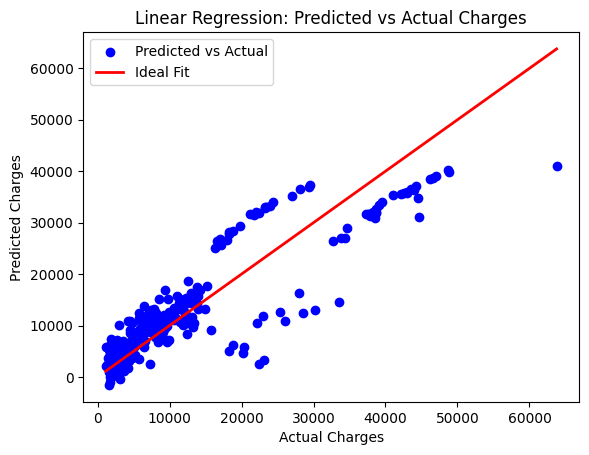

In [11]:
# Visualization

plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2, label='Ideal Fit')

plt.title('Linear Regression: Predicted vs Actual Charges')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.legend()
plt.show()

##### Linear Regression using SGD Regressor in Sklearn

To perform Linear Regression using SGD with Scikit-Learn, you can use the SGDRe
gressor class, which defaults to optimizing the squared error cost function.

In [12]:
# Use  Sklearn

from sklearn.linear_model import  SGDRegressor


# Fit Linear Regression using SGD
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, learning_rate='constant', eta0=0.01)
sgd_reg.fit(X_train, y_train.ravel())
theta_sgd_sklearn = np.concatenate(([sgd_reg.intercept_[0]], sgd_reg.coef_))

print(f"SGD Theta (scikit-learn): {theta_sgd_sklearn}\n")

# Predict using the trained model
y_pred_sklearn = sgd_reg.predict(X_test)

print(f"Predicted values (scikit-learn):\n\n{y_pred_sklearn[0:4]}")

SGD Theta (scikit-learn): [ 9144.93193479  3485.91789944  1195.48805295   398.47565837
  4200.20260575  4802.04518137 -7146.44026152 16148.68804864
  2811.30998456  2651.46155441  1798.03995798  1741.43629016]

Predicted values (scikit-learn):

[ 9670.76891851  7565.92824769 37195.88372272 10803.42272145]


/tmp/ipython-input-1678421798.py:8: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  sgd_reg.fit(X_train, y_train.ravel())


In [13]:

# Fit Linear Regression using SGD with Mini-Batch Gradient Descent
sgd_reg_min_batch = SGDRegressor(
    max_iter=1000,           # Maximum number of iterations
    tol=1e-3,                # Stopping criterion for convergence
    learning_rate='optimal', # Learning rate schedule
    random_state=42          # Ensure reproducibility
)

# Train the model
sgd_reg_min_batch.fit(X_train, y_train.ravel())

# Retrieve the theta values (weights and intercept)
theta_sgd_min_batch = np.concatenate(([sgd_reg_min_batch.intercept_[0]], sgd_reg_min_batch.coef_))

print(f"SGD Theta (Mini-Batch, scikit-learn): {theta_sgd_min_batch}\n")

# Predict using the trained model
y_pred_min_batch = sgd_reg_min_batch.predict(X_test)

print(f"Predicted values (Mini-Batch, scikit-learn): \n {y_pred_min_batch[0:4]}")


SGD Theta (Mini-Batch, scikit-learn): [ 9.54583724e+09 -3.46756736e+04  9.39702267e+04 -1.16532517e+05
 -3.81796897e+09 -3.81810987e+09 -3.81850266e+09 -3.81757618e+09
 -1.90893639e+09 -1.90904173e+09 -1.90896602e+09 -1.90913471e+09]

Predicted values (Mini-Batch, scikit-learn): 
 [ 242789.2115078   427764.90271378 1236788.27315903  -93841.78990173]


/tmp/ipython-input-2455990341.py:10: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  sgd_reg_min_batch.fit(X_train, y_train.ravel())


#### Logistic Regression

In [14]:
data = pd.read_csv('https://raw.githubusercontent.com/NUELBUNDI/Machine-Learning-Data-Set/main/healthcare-dataset-stroke-data.csv')  # For Classification

data.head(2)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1


##### Data Preprocessing

In [15]:
data.drop(columns=['id'],inplace=True)

X = data.drop('stroke',axis=1)
y = data['stroke']

In [16]:
numerical_features_data    =  data.select_dtypes(include=['float64','int64']).columns.to_list()
numerical_features_data.remove('stroke')
categorical_features_data  =  data.select_dtypes(include='object').columns.to_list()


numerical_pipeline    = Pipeline([('imputer', SimpleImputer(strategy='mean')),('scaler', StandardScaler())])
categorical_pipeline  = Pipeline([ ('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([
                                    ('num', numerical_pipeline,  numerical_features_data),
                                    ('cat', categorical_pipeline, categorical_features_data)
                                ])


# Final pipeline including the preprocessor
pipeline = Pipeline([('preprocessor', preprocessor)])


In [17]:
# Fit and transform the data
X_transformed = pipeline.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)

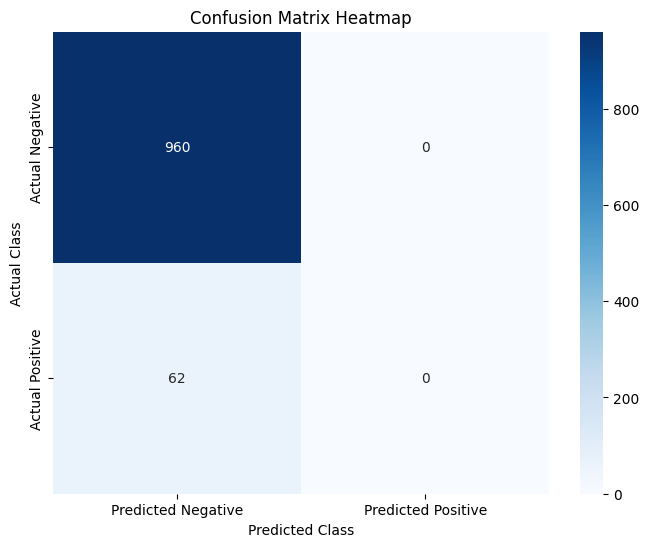

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


# Model Training using Scikit-Learn
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Predictions
y_pred_class = log_reg.predict(X_test)


# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred_class)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))  # Set the figure size
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()


##### Classification Report

In [19]:

# Display Classification Report for additional metrics

print("Classification Report:")
print(classification_report(y_test, y_pred_class))


Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#####  Plot the ROC Curve and Compute AUC

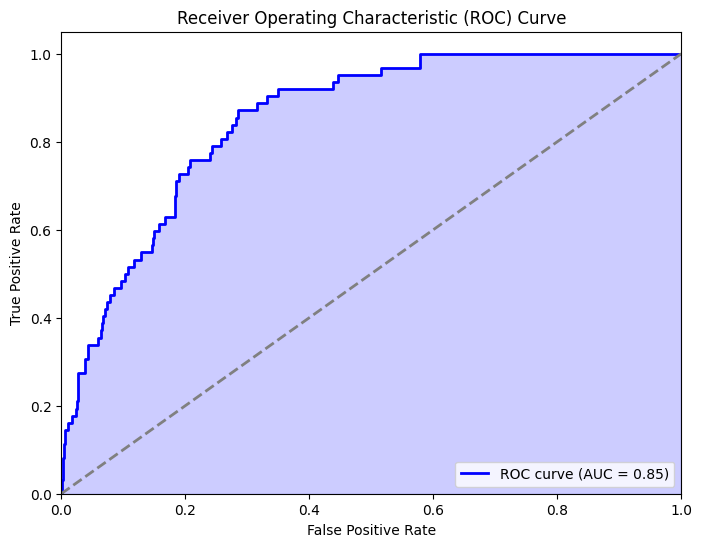

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_proba = log_reg.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class

# Compute ROC Curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Compute AUC
auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC Curve with shaded area
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.2, color='blue')              # Shade the area under the curve
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


- ROC Curve - The ROC curve shows the trade-off between the True Positive Rate (sensitivity) and False Positive Rate (1 - specificity) across different threshold values.

- The AUC value ranges from 0 to 1 A value of 0.5 indicates a model with no discrimination ability (random guessing), while a value of 1.0 indicates perfect classification. Higher AUC values generally indicate better model performance.